In [1]:
from RDT import get_rdts
import copy
import at
import numpy as np
ring = at.load_lattice('betamodel.mat', use='betamodel')
# --- Get element indices ---
elements_ind = at.get_refpts(ring, "*")
cor_indices = at.get_refpts(ring, 'S[FIJ]2A*')
Corords = [cor_indices,cor_indices]
used_bpm = at.get_refpts(ring, at.elements.Monitor)
QD3 = at.get_refpts(ring, 'QD3[AE]*')
QF4 = at.get_refpts(ring, 'QF4[ABDE]*')
QD5 = at.get_refpts(ring, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
CAVords = at.get_refpts(ring, at.elements.RFCavity)
skew_ord = at.get_refpts(ring, 'S[HFDIJ]*')
ring_pyloco3 = at.load_lattice('ring_pyloco3.mat', use='ring')

skew_err = []
for i in skew_ord:
    skew_err.append((ring_pyloco3[i].PolynomA[1])*ring_pyloco3[i].Length)

quads_err = []
for i in quad_indices:
    quads_err.append((ring_pyloco3[i].PolynomB[1] - ring[i].PolynomB[1] )*ring_pyloco3[i].Length)

Lattice tune after loco : [0.16141398 0.33776818]


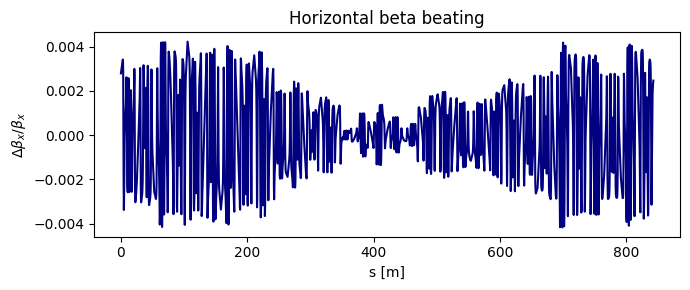

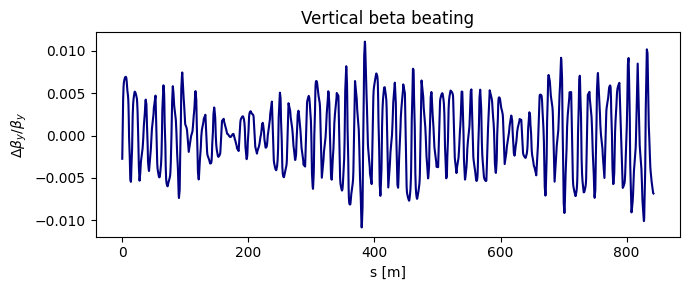

In [2]:
print('Lattice tune after loco :' , at.get_tune(ring_pyloco3))
import matplotlib.pyplot as plt

def plot_data(s_pos, data, xlabel, ylabel, title):
    plt.figure(figsize=(7, 3))
    plt.plot(s_pos, data, color='navy')  # Deep blue color
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    # plt.grid(True, which='both', linestyle=':', color='gray')
    plt.tight_layout()
    plt.show()

_, _, twiss = at.get_optics(ring, elements_ind)
_, _, twiss_err = at.get_optics(ring_pyloco3, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0] - twiss.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1] -  twiss.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")

In [3]:
numberOfIteration = 5
cut = 96
dcS_rdts = np.zeros(len(skew_ord))

for x in range(numberOfIteration):

    #correct_tune_and_orbit(SC, ORM=ORM, alpha=10)
    #for _ in range(5):
    #  SC.tuning.tune.correct(n_iter=1, gain=0.5,  measurement_method='cheat')
    #SC.tuning.correct_orbit(method = 'svd_values', parameter=1500, n_reps=10, gain=1)

    print("---------------RDT Coupling Corrections---------------")
    [elemdata0, beamdata, elemdata] = at.get_optics(ring, used_bpm)
    dy_c0 = elemdata.dispersion[:, 2]

    F1001C, F1010C, f2000C, f0020C = get_rdts(ring_pyloco3, used_bpm)
    F1001R_c = np.real(F1001C)
    F1001I_c = np.imag(F1001C)
    F1010R_c = np.real(F1010C)
    F1010I_c = np.imag(F1010C)
    difference = np.array([F1001R_c, F1001I_c])
    addit = np.array([F1010R_c, F1010I_c])

    print("err F1001R_c:", F1001R_c[100])
    print("err F1001I_c:", F1001I_c[100])
    print("err F1010R_c:", F1010R_c[100])
    print("err F1010I_c:", F1010I_c[100])

    response_matrix_rdts = np.hstack(
        (np.load('difference_ebs.npy'), np.load('addit_ebs.npy'), np.load('Etay_ebs.npy')))

    u, s, vh = np.linalg.svd(response_matrix_rdts, full_matrices=False)

    F1001C, F1010C, f2000C, f0020C = get_rdts(ring_pyloco3, used_bpm)
    F1001R_c = np.real(F1001C)
    F1001I_c = np.imag(F1001C)
    F1010R_c = np.real(F1010C)
    F1010I_c = np.imag(F1010C)
    difference = np.array([F1001R_c, F1001I_c])
    addit = np.array([F1010R_c, F1010I_c])
    [elemdata0, beamdata, elemdata] = at.get_optics(ring_pyloco3, used_bpm)
    dy_c = elemdata.dispersion[:, 2]
    measured = np.concatenate((difference.flatten(), addit.flatten(), (dy_c - dy_c0)), axis=0)
    dcS = 0 + np.linalg.pinv(response_matrix_rdts.T, rcond=s[cut - 1] / s[0]) @ measured

    for count, ic in enumerate(skew_ord):
        dcS_rdts[count] += dcS[count] * ring_pyloco3[ic].Length
        a = ring_pyloco3[ic].PolynomA[1]
        ring_pyloco3[ic].PolynomA[1] = a - dcS[count]


F1001C, F1010C, f2000C, f0020C = get_rdts(ring_pyloco3, used_bpm)
F1001R_c = np.real(F1001C)
F1001I_c = np.imag(F1001C)
F1010R_c = np.real(F1010C)
F1010I_c = np.imag(F1010C)
print("First element of F1001R_c:", F1001R_c[100])
print("First element of F1001I_c:", F1001I_c[100])
print("First element of F1010R_c:", F1010R_c[100])
print("First element of F1010I_c:", F1010I_c[100])

---------------RDT Coupling Corrections---------------
err F1001R_c: -0.0014563999945416295
err F1001I_c: 0.00019271113350085586
err F1010R_c: -0.0001398063274299779
err F1010I_c: -0.0020618994550812043
---------------RDT Coupling Corrections---------------
err F1001R_c: -0.0006583587656050379
err F1001I_c: -0.00017306582587955295
err F1010R_c: 4.8828343480260206e-05
err F1010I_c: 4.643031310282514e-05
---------------RDT Coupling Corrections---------------
err F1001R_c: -0.0006623539898054442
err F1001I_c: -0.00012164084576357832
err F1010R_c: 5.7330117429046035e-05
err F1010I_c: 4.507922697801637e-05
---------------RDT Coupling Corrections---------------
err F1001R_c: -0.0006622095916730106
err F1001I_c: -0.00012370036975446855
err F1010R_c: 5.7285584237870245e-05
err F1010I_c: 4.503289579667238e-05
---------------RDT Coupling Corrections---------------
err F1001R_c: -0.000662215379203723
err F1001I_c: -0.00012361618364236296
err F1010R_c: 5.728668814246542e-05
err F1010I_c: 4.5035120

In [4]:
# optics correction
from RDT import get_rdts
import copy

[elemdata0, beamdata, elemdata] = at.get_optics(ring, used_bpm)
mux0 = elemdata.mu[:, 0] / (2 * np.pi)
muy0 = elemdata.mu[:, 1] / (2 * np.pi)
Eta_xx0 = elemdata.dispersion[:, 0]
beta_x0 = elemdata.beta[:, 0]
beta_y0 = elemdata.beta[:, 1]

dcS_phase = np.zeros(len(quad_indices))


mux0_diff = np.append(np.diff(mux0), mux0[-1] - mux0[0])
muy0_diff = np.append(np.diff(muy0), muy0[-1] - muy0[0])
cut = 96
phase_iter = 5
for x in range(phase_iter):

    #print('Before_correction')
    _, _, twiss0 = at.get_optics(ring, elements_ind)
    Px = np.load('Px_ebs.npy')
    Py = np.load('Py_ebs.npy')
    Etax = np.load('Etax_ebs.npy')

    response_matrix = np.hstack((Px, Py, Etax))
    u, s, vh = np.linalg.svd(response_matrix, full_matrices=False)

    [elemdata0, beamdata, elemdata] = at.get_optics(ring_pyloco3, used_bpm)
    mux = elemdata.mu[:, 0] / (2 * np.pi)
    muy = elemdata.mu[:, 1] / (2 * np.pi)
    Eta_xx = elemdata.dispersion[:, 0]
    beta_x = elemdata.beta[:, 0]
    beta_y = elemdata.beta[:, 1]

    mux_diff = np.append(np.diff(mux), mux[-1] - mux[0])
    muy_diff = np.append(np.diff(muy), muy[-1] - muy[0])

    mux1 = mux_diff - mux0_diff
    muy1 = muy_diff - muy0_diff

    phase_advance = np.concatenate((mux1, muy1,  (Eta_xx - Eta_xx0)),
                                   axis=0)
    dcS = 0 + np.linalg.pinv(response_matrix.T, rcond=s[cut - 1] / s[0]) @ (phase_advance)
    for count, ic in enumerate(quad_indices):
        dcS_phase[count] += dcS[count] * ring_pyloco3[ic].Length
        a = ring_pyloco3[ic].PolynomB[1]
        ring_pyloco3[ic].PolynomB[1] = a - dcS[count]


Before_correction
Before_correction
Before_correction
Before_correction
Before_correction


Lattice tune after loco : [0.15999574 0.34012127]


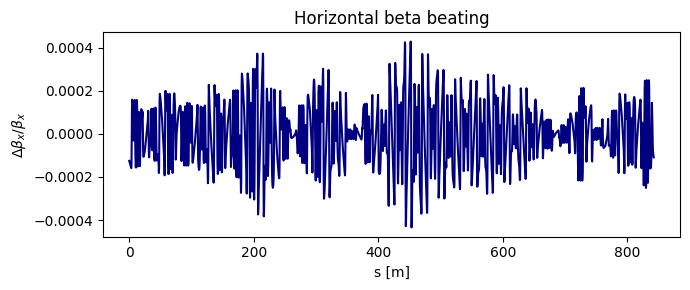

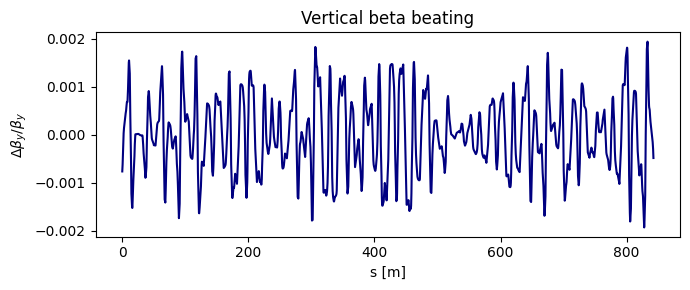

In [5]:
print('Lattice tune after loco :' , at.get_tune(ring_pyloco3))
import matplotlib.pyplot as plt

def plot_data(s_pos, data, xlabel, ylabel, title):
    plt.figure(figsize=(7, 3))
    plt.plot(s_pos, data, color='navy')  # Deep blue color
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    # plt.grid(True, which='both', linestyle=':', color='gray')
    plt.tight_layout()
    plt.show()

_, _, twiss = at.get_optics(ring, elements_ind)
_, _, twiss_err = at.get_optics(ring_pyloco3, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0] - twiss.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1] -  twiss.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")

In [6]:
len(dcS_rdts)

288

In [7]:
len(Skew)

NameError: name 'Skew' is not defined

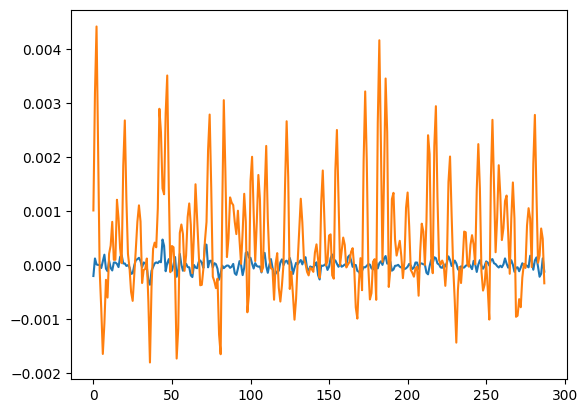

In [8]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
data = loadmat("EBS_QuadCorStrengths.mat") # The ORM measurment was taken after appling this correction
Kq0L = data["Kq0L"]
Quad = data["Quad"]
Skew = data["Skew"]
quad_cor = Quad - Kq0L
plt.plot(dcS_rdts)
plt.plot(Skew)

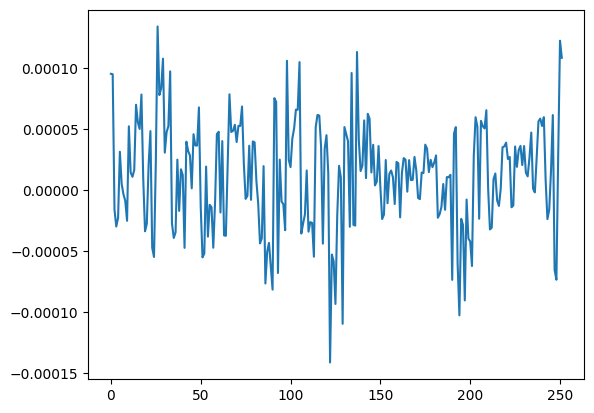

In [9]:
plt.plot(dcS_phase)

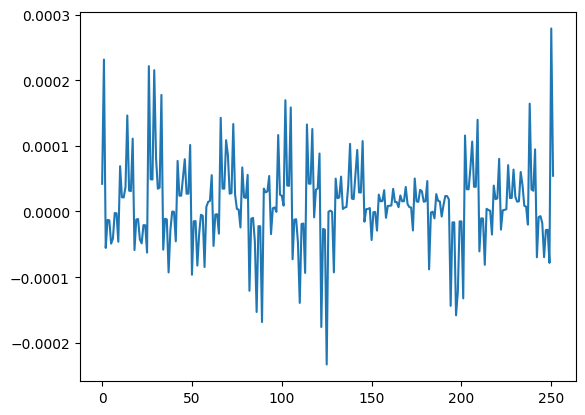

In [36]:
plt.plot(quads_err)